# **Influencer Performance & Segmentation for Marketing Campaigns**

> Project ini bertujuan untuk menganalisis performa influencer dari 1000 akun media sosial, menggunakan metrik seperti engagement rate, followers, dan jumlah posting. Analisis ini dapat membantu brand memilih platform dan influencer yang paling efektif dalam campaign marketing mereka.

# **Import Library & Load Data**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving social media influencers - Tiktok sep 2022.csv to social media influencers - Tiktok sep 2022.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('social media influencers - Tiktok sep 2022.csv')
df.head()

,S.no,Tiktoker name,Tiktok name,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.
0,1,jypestraykids,Stray Kids,13.8M,6.4M,2.3M,50.2K,34.2K
1,2,khaby.lame,Khabane lame,149.2M,17.3M,2.3M,15.2K,8.7K
2,3,scarlettsspam2,scarlett,2.1M,17.9M,845.8K,53.9K,6.3K
3,4,addisonre,Addison Rae,88.7M,22M,906.6K,7.6K,26.2K
4,5,belindatok,Belinda,4.8M,14.2M,1.5M,14.5K,15.3K


In [ ]:
df.tail()

,S.no,Tiktoker name,Tiktok name,Subscribers,Views avg.,Likes avg.,Comments avg.,Shares avg.
995,996,brendadialoy,Brenda Dialoy,371.9K,1.2M,187.5K,626,2K
996,997,jujufitcats,Juju Fitcats,4.3M,2.2M,280.8K,380,558
997,998,xoteam,XO Team,37.8M,2.5M,180.2K,859,450
998,999,kimsnwuo,️️,100.9K,957.4K,226.8K,908,1.7K
999,1000,jass_mcg,jass_mcg,52.2K,503.8K,116K,8.1K,1.8K


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   S.no           1000 non-null   int64 
 1   Tiktoker name  1000 non-null   object
 2   Tiktok name    999 non-null    object
 3   Subscribers    1000 non-null   object
 4   Views avg.     1000 non-null   object
 5   Likes avg.     1000 non-null   object
 6   Comments avg.  1000 non-null   object
 7   Shares avg.    1000 non-null   object
dtypes: int64(1), object(7)
memory usage: 62.6+ KB


> **Dataset TikTok Influencer pada 2022 ini berisi 1000 baris dan 8 kolom.**

* Terdapat satu kolom hilang pada bagian: 'Tiktok name'.
* Kolom-kolom yang seharusnya berisi angka ('Subscribers', 'Views avg.', 'Likes avg.', 'Comments avg.', 'Shares avg.') saat ini disimpan sebagai teks (object). Dikarenakan data yang disimpan berbentuk '371.9K',	'1.2M',	'187.5K',	'626	2K' (Tidak hanya numerik).

# **Data Cleaning & Preprocessing**

In [ ]:
# Mengonversi Kolom String Dengan 'M' dan 'K' Menjadi Numerik
def convert_subscriber_format(value):
    if 'M' in str(value):
        return float(str(value).replace('M', '')) * 1_000_000
    elif 'K' in str(value):
        return float(str(value).replace('K', '')) * 1_000
    return float(value)

df['Subscribers'] = df['Subscribers'].apply(convert_subscriber_format)
df['Views avg.'] = df['Views avg.'].apply(convert_subscriber_format)
df['Likes avg.'] = df['Likes avg.'].apply(convert_subscriber_format)
df['Comments avg.'] = df['Comments avg.'].apply(convert_subscriber_format)
df['Shares avg.'] = df['Shares avg.'].apply(convert_subscriber_format)

In [ ]:
# Pembersihan Data
print(df.isnull().sum())

S.no             0
Tiktoker name    0
Tiktok name      1
Subscribers      0
Views avg.       0
Likes avg.       0
Comments avg.    0
Shares avg.      0
dtype: int64


In [ ]:
df.dropna(subset=['Tiktok name'], inplace=True)

In [ ]:
print(df.isnull().sum())

S.no             0
Tiktoker name    0
Tiktok name      0
Subscribers      0
Views avg.       0
Likes avg.       0
Comments avg.    0
Shares avg.      0
dtype: int64


# **Exploratory Data Analysis (EDA)**

> **Statistik Deskriptif**

In [ ]:
df['Comments avg.'].describe()

,Comments avg.
count,999.000000
mean,2537.766767
std,3692.961026
min,0.000000
25%,984.000000
50%,1600.000000
75%,2700.000000
max,53900.000000


> **Deskripsi Data Comments Average**

* **count:** Jumlah entri yang tidak kosong dalam kolom 'Comments avg.', yaitu 999. Ini menunjukkan bahwa ada satu baris yang memiliki nilai kosong di kolom ini.

* **mean:** Rata-rata jumlah komentar per postingan untuk semua influencer adalah sekitar 2537.77.

* **std:** Standar deviasi, sekitar 3692.96, mengukur sebaran data. Standar deviasi yang relatif besar dibandingkan dengan rata-rata menunjukkan bahwa rata-rata jumlah komentar bervariasi secara signifikan di antara para influencer.

* **min:** Jumlah rata-rata komentar minimum adalah 0.

* **25%:** Kuartil pertama (Q1) adalah 984. Ini berarti 25% influencer memiliki rata-rata 984 komentar atau kurang.

* **50%:** Median (Q2) adalah 1600. Ini adalah nilai tengah dari dataset ketika diurutkan, menunjukkan bahwa setengah dari influencer memiliki rata-rata 1600 komentar atau kurang. Median lebih rendah dari rata-rata, yang menunjukkan bahwa data kemungkinan miring ke kanan (right-skewed), artinya ada beberapa influencer dengan rata-rata komentar yang sangat tinggi yang menarik rata-rata ke atas.

* **75%:** Kuartil ketiga (Q3) adalah 2700. Ini berarti 75% influencer memiliki rata-rata 2700 komentar atau kurang.

* **max:** Jumlah rata-rata komentar maksimum adalah 53900. Ini menyoroti keberadaan outlier atau influencer dengan engagement yang luar biasa tinggi dalam hal komentar.

> **Distribusi Followers**

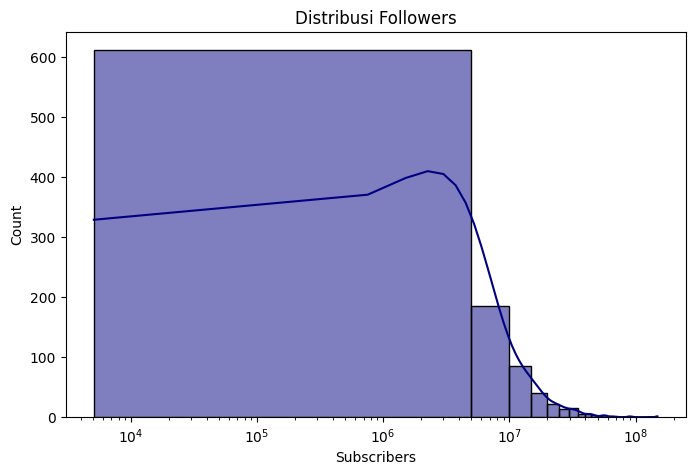

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Subscribers'], bins=30, kde=True, color='navy')
plt.title("Distribusi Followers")
plt.xscale('log')  # Untuk Memperjelas Distribusi
plt.show()

> **Penjelasan Grafik Distribusi Followers**

* Berdasarkan grafik distribusi jumlah followers dalam skala logaritmik, **mayoritas influencer memiliki kurang dari 100 ribu pengikut.** Distribusi ini menunjukkan pola *positively skewed*, menandakan dominasi mikro hingga mid-tier influencer dalam populasi.

* **Puncak distribusi berada pada rentang followers rendah-menengah**, konsisten dengan karakteristik media sosial di mana pengguna dengan audiens niche lebih banyak daripada selebriti dengan jutaan pengikut. Temuan ini menyiratkan bahwa *strategi pemasaran berbasis mikro-influencer dapat memberikan efektivitas dan efisiensi biaya yang lebih tinggi.*

> **Korelasi Antar Variabel**

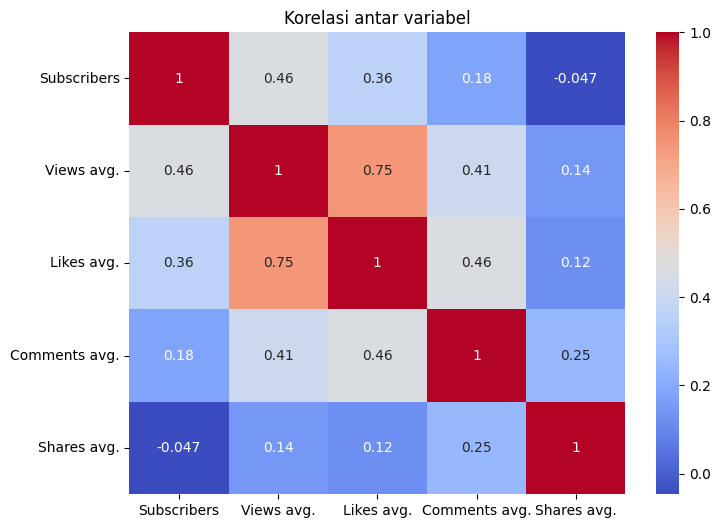

In [ ]:
numeric_df = df[['Subscribers', 'Views avg.', 'Likes avg.', 'Comments avg.', 'Shares avg.']]

# Korelasi Antar Variabel Numerik
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Korelasi antar variabel")
plt.show()

> **Interpretasi Korelasi Antar Variabel Influencer**

**Heatmap korelasi** menunjukkan hubungan antar metrik performa influencer seperti jumlah subscribers, rata-rata views, likes, comments, dan shares. Dari visualisasi ini, dapat disimpulkan bahwa:

1. **Korelasi tertinggi (0.75)** terjadi antara views rata-rata dan likes rata-rata, menunjukkan bahwa semakin tinggi jumlah penonton konten, semakin besar pula kemungkinan konten tersebut mendapatkan likes. Hal ini sangat masuk akal karena views menjadi prasyarat bagi interaksi lainnya.

2. **Subscribers** memiliki **korelasi sedang** dengan views (0.46) dan likes (0.36), tetapi rendah dengan comments (0.18) serta negatif dengan shares (-0.047). Artinya, meskipun memiliki banyak pengikut, tidak selalu menjamin tingginya interaksi—terutama dalam bentuk komentar dan share. Ini mengindikasikan bahwa jumlah pengikut bukan satu-satunya indikator engagement yang kuat.

3. **Comments dan likes (0.46)** memiliki **hubungan yang cukup kuat**, menandakan bahwa konten yang disukai juga cenderung mengundang lebih banyak komentar.

4. **Shares** merupakan metrik dengan **korelasi paling lemah** terhadap semua variabel lain. Nilai korelasinya sangat rendah bahkan negatif terhadap subscribers. Ini menunjukkan bahwa keputusan untuk membagikan konten lebih bersifat selektif dan mungkin dipengaruhi oleh faktor lain seperti emosionalitas konten, daya tarik visual, atau viral value, bukan sekadar seberapa populer akun tersebut.


---


> **Jumlah subscribers** memang penting sebagai ukuran popularitas, tetapi engagement sejati lebih tercermin dari interaksi seperti likes, comments, dan shares—yang ternyata tidak selalu linier terhadap jumlah pengikut. Untuk analisis performa influencer, rata-rata views dan likes bisa dianggap sebagai indikator engagement yang lebih relevan dibanding subscribers.

> **Top 10 Influencers by Followers**

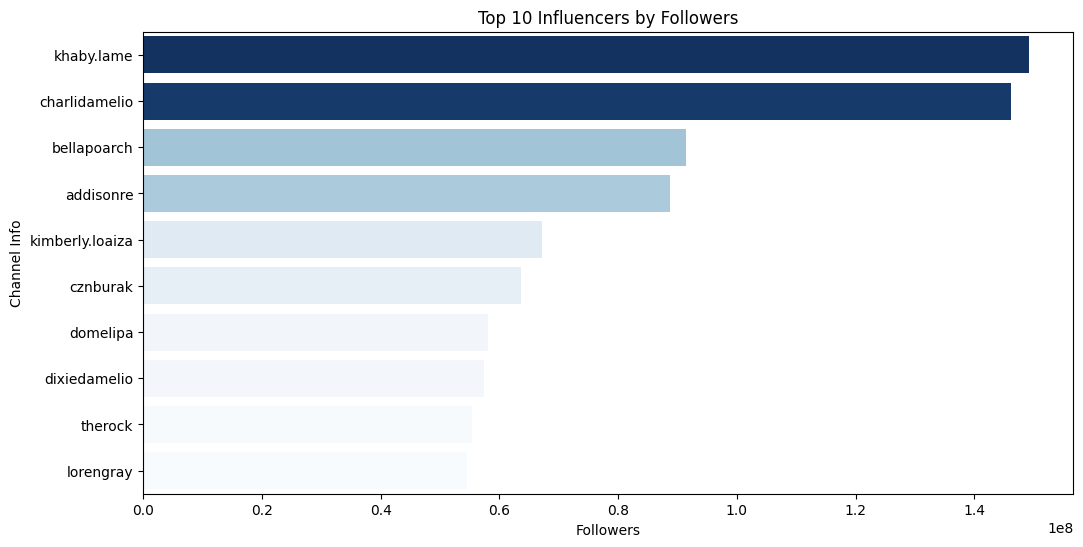

In [ ]:
plt.figure(figsize=(12, 6))
top_10_subscribers = df.sort_values(by='Subscribers', ascending=False).head(10)

# Tetapkan 'Followers'
sns.barplot(x='Subscribers', y='Tiktoker name', data=top_10_subscribers, hue='Subscribers', palette='Blues', legend=False)
plt.title('Top 10 Influencers by Followers')
plt.xlabel('Followers')
plt.ylabel('Channel Info')
plt.show()

> **Top 10 Influencer Berdasarkan Pengikut**

* Grafik bar horizontal tersebut menunjukkan sepuluh akun TikTok dengan jumlah pengikut (followers) terbanyak. Di **posisi teratas** adalah **khaby.lame**, yang menempati peringkat pertama dengan lebih dari 150 juta pengikut. Diikuti oleh charlidamelio, yang sebelumnya dikenal sebagai pemilik akun dengan followers terbanyak, dengan angka yang juga mendekati Khaby. Dan lain sebagainya.

* Pola ini menunjukkan bahwa meskipun sebagian besar nama di daftar ini adalah content creator atau selebritas TikTok, kehadiran tokoh seperti therock yang berasal dari industri hiburan memperlihatkan bagaimana **popularitas di luar platform** juga dapat **berdampak signifikan** terhadap jumlah pengikut.

* Secara keseluruhan, grafik ini menegaskan bahwa **jumlah followers adalah indikator kuat dari jangkauan sosial**, namun *tidak selalu berkorelasi* langsung dengan engagement seperti *likes atau shares*, seperti yang telah diungkap pada analisis korelasi sebelumnya.

> **Top Influencers by Views vs Likes**

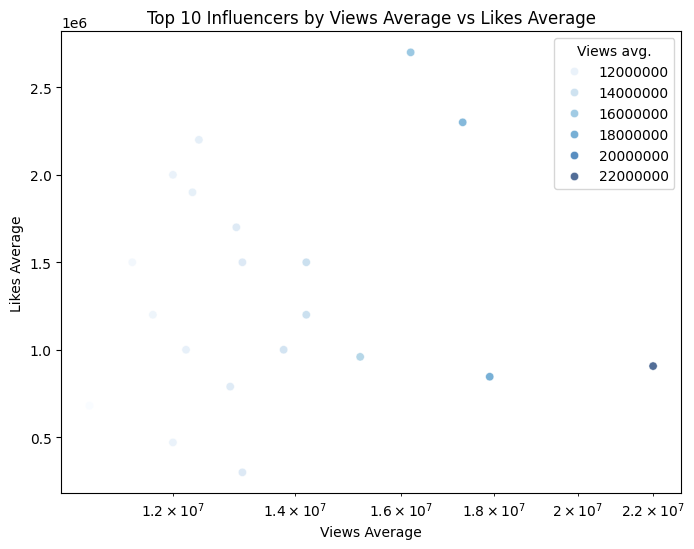

In [ ]:
top_10_views = df.sort_values(by='Views avg.', ascending=False).head(20)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=top_10_views, x='Views avg.', y='Likes avg.', hue='Views avg.', palette='Blues', alpha=0.7)
plt.title("Top 10 Influencers by Views Average vs Likes Average")
plt.xlabel("Views Average")
plt.ylabel("Likes Average")
plt.xscale("log")
plt.show()

> **Top 10 Influencer Berdasarkan Pengikut**

* Grafik scatter plot menggambarkan **hubungan antara rata-rata jumlah tayangan (views average) dan rata-rata jumlah suka (likes average)** dari 10 influencer teratas. Setiap titik merepresentasikan satu influencer, dengan ukuran dan warna titik mencerminkan besar views average.

* Secara umum, terdapat tren positif bahwa semakin tinggi rata-rata views, semakin tinggi pula rata-rata likes, meskipun hubungan ini tidak selalu linier. **Terdapat beberapa influencer dengan views yang sangat tinggi namun jumlah likes yang relatif lebih rendah**, yang bisa menjadi indikasi rendahnya tingkat keterlibatan (engagement) audiens terhadap kontennya.

* Sebaliknya, ada pula **influencer dengan views yang sedang namun memiliki tingkat likes yang tinggi**, menunjukkan bahwa audiens mereka lebih terlibat dan responsif terhadap konten. Grafik ini memberikan gambaran penting bahwa **tingginya views belum tentu menjamin engagement yang tinggi**, sehingga analisis performa influencer sebaiknya mempertimbangkan kedua metrik ini secara bersamaan untuk evaluasi yang lebih menyeluruh.

> **Boxplot Followers Distribution**

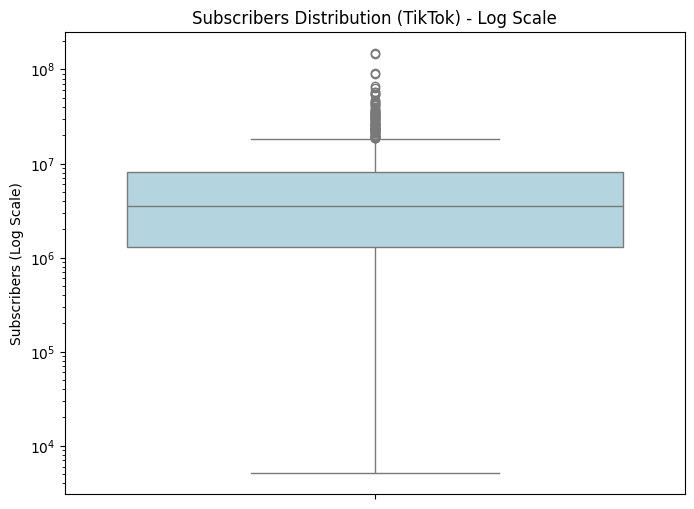

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Subscribers', color='lightblue')
plt.title("Subscribers Distribution (TikTok) - Log Scale")
plt.ylabel("Subscribers (Log Scale)")

# Gunakan Skala Logaritmik Untuk Sumbu Y
plt.yscale("log")
plt.show()

> **Top 10 Influencer Berdasarkan Pengikut**

* Visualisasi boxplot ini menunjukkan **distribusi jumlah subscribers** untuk akun TikTok, menggunakan skala logaritmik pada sumbu Y. Skala log dipakai karena data subscribers memiliki rentang yang sangat luas, dari ribuan hingga ratusan juta. Mayoritas influencer memiliki jumlah subscribers di kisaran satu hingga sepuluh juta, sebagaimana terlihat dari bagian tengah boxplot (interquartile range).

* Sementara itu, **terdapat banyak outlier di atas nilai maksimum whisker**, yang menunjukkan adanya akun-akun dengan subscribers sangat tinggi dan tergolong sebagai mega influencer. Penggunaan **log scale** membantu *memperjelas variasi di antara akun yang memiliki jumlah followers* menengah ke bawah, yang biasanya sulit dibedakan jika menggunakan skala linier. Secara keseluruhan, data ini menunjukkan **distribusi yang right-skewed**, di mana sebagian kecil akun menguasai sebagian besar jumlah subscribers.

# **Influencer Segmentation (K-Means Clustering)**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

features = ['Subscribers', 'Views avg.', 'Likes avg.', 'Comments avg.']
X = df[features].dropna()

In [ ]:
# Standarisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

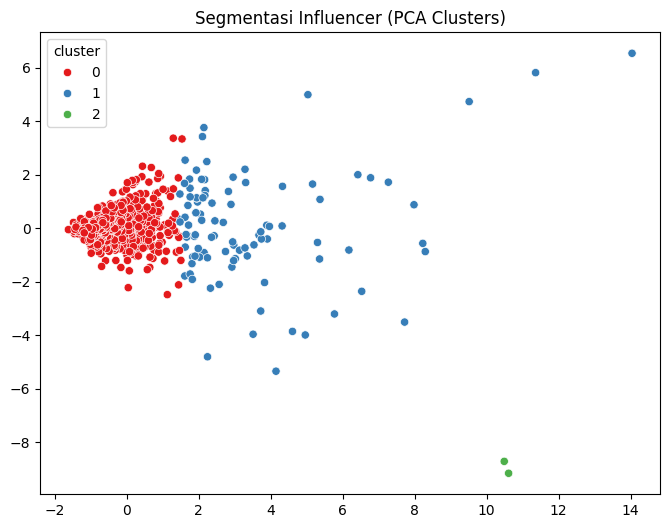

In [ ]:
# Visualisasi Clustering
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster'], palette="Set1")
plt.title("Segmentasi Influencer (PCA Clusters)")
plt.show()

> **Interpretasi Clustering Influencer (PCA 2D)**

Grafik ini menampilkan **hasil segmentasi influencer TikTok** ke dalam 3 klaster, yang divisualisasikan menggunakan Principal Component Analysis (PCA) untuk mereduksi dimensi data menjadi 2 komponen utama.

* **Cluster 0 (hijau):**
Merupakan kelompok influencer yang cenderung homogen, terkonsentrasi rapat di pusat plot. Mereka kemungkinan memiliki jumlah views, likes, dan engagement yang **cukup seimbang.** Ini bisa jadi representasi influencer kelas menengah yang aktif dan stabil.

* **Cluster 1 (orange):**
Terlihat lebih tersebar luas ke kanan dan bawah, mencerminkan **variabilitas tinggi dalam metrik mereka.** Bisa terdiri dari influencer dengan strategi konten atau niche yang lebih bervariasi, atau bahkan mereka yang sedang naik daun maupun sudah sangat populer (tapi tidak ekstrem).

* **Cluster 2 (biru):**
Hanya terdiri dari sedikit **data point yang sangat terpisah** dari cluster lainnya, menunjukkan bahwa influencer dalam cluster ini punya karakteristik sangat unik dan ekstrem — kemungkinan besar ini adalah top-tier influencer dengan jutaan followers dan engagement luar biasa tinggi (**superstar**).

R-squared: 0.5286326885498576
RMSE: 1483469.8999966078


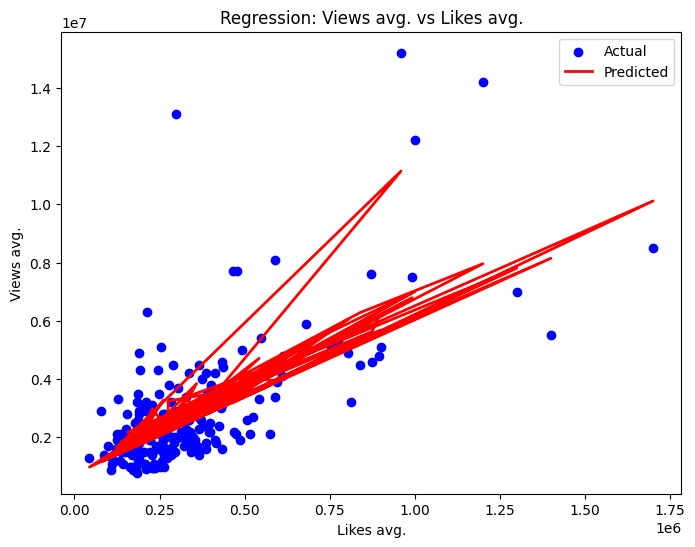

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Pilih Fitur dan Target Untuk Regresi Dengan Korelasi Tertinggi
features_reg = ['Likes avg.', 'Subscribers']
target_reg = 'Views avg.'

# Pastikan Kolomnya Ada dan Tangani Potensi NaN Jika Belum Dilakukan
if all(col in df.columns for col in features_reg + [target_reg]):
    df_reg = df[features_reg + [target_reg]].dropna()

    # Tentukan X dan Y Untuk Model Regresi
    X_reg = df_reg[features_reg]
    y_reg = df_reg[target_reg]

    # Membagi Data ke Dalam Set Pelatihan dan Pengujian
    X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

    # Inisialisasi dan Latih Model Regresi Linear
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Membuat Prediksi pada Set Pengujian
    y_pred = model.predict(X_test)

    # Mengevaluasi Model
    r_squared = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"R-squared: {r_squared}")
    print(f"RMSE: {rmse}")

    # Memvisualisasikan Hasil Regresi
    plt.figure(figsize=(8, 6))
    plt.scatter(X_test[features_reg[0]], y_test, color='blue', label='Actual')
    plt.plot(X_test[features_reg[0]], y_pred, color='red', linewidth=2, label='Predicted')
    plt.title(f'Regression: {target_reg} vs {features_reg[0]}')
    plt.xlabel(features_reg[0])
    plt.ylabel(target_reg)
    plt.legend()
    plt.show()
else:
    print("Required columns for regression are not present in the DataFrame.")

> **Interpretasi Regresi dari Average Likes dan Views Average**

* **R-squared:** Sekitar 56% dari **perbedaan jumlah rata-rata suka antar influencer** dapat *dijelaskan* oleh kombinasi variabel prediktor yang Anda gunakan, yaitu "Subscribers" dan "Views avg." Artinya, model cukup baik dalam menangkap hubungan antara jumlah pengikut, rata-rata tayangan, dan rata-rata suka. Namun, masih ada sekitar 44% variasi rata-rata suka yang tidak dapat dijelaskan oleh kedua variabel tersebut. Hal ini menandakan ada faktor lain yang memengaruhi rata-rata suka yang tidak termasuk dalam model Anda.

* **RMSE:** Karena rata-rata suka dalam dataset jutaan, maka kesalahan 1.4 jutaan dianggap wajar. Namun, jika rata-rata suka umumnya lebih rendah, maka kesalahan ini bisa dikatakan cukup besar.

> **Kesimpulan:** Model regresi menunjukkan kinerja yang cukup baik dengan R-squared sekitar 56%. Ini berarti kedua variabel tersebut memiliki kekuatan yang signifikan dalam menjelaskan variasi rata-rata suka. **Namun,** nilai RMSE yang sekitar 1.4 jutaan menunjukkan bahwa masih ada tingkat kesalahan dalam prediksi model Anda. Untuk meningkatkan akurasi model, Anda bisa mempertimbangkan menambahkan variabel lain atau mencoba teknik pemodelan yang berbeda.

# **Perhitungan Engagement Rate**

In [ ]:
# Hitung total engagement
df['Total Engagement'] = df['Likes avg.'] + df['Comments avg.'] + df['Shares avg.']

# Engagement rate berdasarkan subscriber
df['Engagement Rate'] = df['Total Engagement'] / df['Subscribers']

# Engagement rate (%) agar lebih mudah dibaca
df['Engagement Rate (%)'] = df['Engagement Rate'] * 100
df[['Tiktoker name', 'Subscribers', 'Total Engagement', 'Engagement Rate (%)']].head()

,Tiktoker name,Subscribers,Total Engagement,Engagement Rate (%)
0,jypestraykids,13800000.0,2384400.0,17.278261
1,khaby.lame,149200000.0,2323900.0,1.557574
2,scarlettsspam2,2100000.0,906000.0,43.142857
3,addisonre,88700000.0,940400.0,1.060203
4,belindatok,4800000.0,1529800.0,31.870833


> **Interpretasi Nilai Engagement Rate**

* Influencer dengan subscriber besar tidak selalu punya engagement rate tinggi. **Contohnya,** scarlettsspam2 dan belindatok menunjukkan bahwa akun dengan komunitas kecil-menengah bisa jauh lebih engaged. *Engagement Rate bisa digunakan sebagai indikator performa aktual*, bukan hanya **popularitas.**

# **Mendeteksi Outliers**

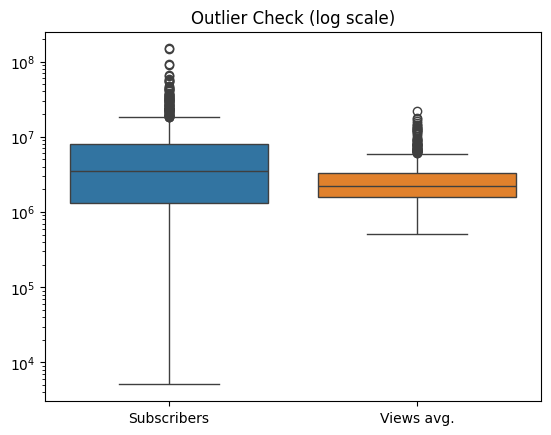

In [ ]:
sns.boxplot(data=df[['Subscribers', 'Views avg.']])
plt.yscale('log')
plt.title('Outlier Check (log scale)')
plt.show()

> **Interpretasi per Variabel**

1. **Followers:** Median Followers ada di **sekitar 3 juta–5 juta (dalam skala log)**. Dengan sebaran followers cukup lebar, mulai dari ribuan hingga ratusan juta, terlihat dari whiskers yang panjang. **Banyak outlier ekstrim** di atas (lingkaran hitam di atas boxplot), mengindikasikan keberadaan super influencer dengan **followers sangat tinggi** (misalnya di atas 30 juta bahkan 100 juta). Distribusi ini right-skewed — mayoritas influencer berada di bawah 10 juta subscriber.

2. **Views Average:** Median rata-rata views **lebih rendah dari subscriber** (sekitar 1–2 juta). Variasi views juga signifikan, tapi tidak sebesar followers. Ada outlier juga, namun lebih sedikit dan tidak se-ekstrem followers, yang menunjukkan bahwa *tidak semua followers aktif menonton setiap video.*


# **Menganalisis Korelasi Antar Metriks Data**

In [ ]:
print(df[['Subscribers', 'Likes avg.', 'Views avg.']].corr())

             Subscribers  Likes avg.  Views avg.
Subscribers     1.000000    0.362128    0.461075
Likes avg.      0.362128    1.000000    0.746231
Views avg.      0.461075    0.746231    1.000000


> **Interpretasi Nilai Engagement Rate**

* Dari matriks korelasi ini, dapat disimpulkan bahwa **rata-rata Views** memiliki hubungan **korelasi yang paling kuat** dengan **rata-rata Likes.** Sementara itu, jumlah Subscribers memiliki korelasi yang lebih lemah dengan Likes maupun Views dibandingkan korelasi antara Likes dan Views itu sendiri. Ini mengindikasikan bahwa faktor selain jumlah pengikut juga berperan penting dalam menentukan seberapa banyak video ditonton dan disukai.

In [ ]:
# Rata-rata metrik per cluster
cluster_summary = df.groupby('cluster')[['Subscribers', 'Views avg.', 'Likes avg.', 'Comments avg.', 'Engagement Rate (%)']].mean()
print(cluster_summary)

          Subscribers    Views avg.    Likes avg.  Comments avg.  \
cluster                                                            
0        5.481229e+06  2.329656e+06  2.827510e+05    1958.024499   
1        2.167232e+07  7.443434e+06  9.618081e+05    6796.191919   
2        7.950000e+06  1.215000e+07  1.572900e+06   52050.000000   

         Engagement Rate (%)  
cluster                       
0                  60.994762  
1                  35.958753  
2                  30.210559  


> **Interpretasi Klaster Influencer**

* Klaster 0 terdiri dari influencer dengan **jumlah subscriber menengah**, namun memiliki *engagement rate yang sangat tinggi*. Meskipun views dan likes tidak setinggi klaster lain, tingkat keterlibatan pengikut mereka sangat tinggi. Ini bisa berarti mereka punya audiens yang sangat loyal dan aktif.

* Influencer dalam klaster 2 memiliki **basis subscriber besar dan engagement rate cukup baik.** Mereka seimbang antara reach dan interaksi, cocok untuk kampanye dengan tujuan visibilitas luas dan interaksi yang solid.

* **Klaster 1 dengan views tertinggi**, bahkan melampaui jumlah subscribernya. Artinya, konten dari klaster ini sering masuk FYP atau viral, menjangkau jauh lebih banyak orang daripada hanya pengikut. Cocok untuk campaign yang ingin viral reach, meskipun engagement rate sedikit lebih rendah.

